# Machine Learning Coursework 1: Predicting the max temperature at La Guardia Airport
**Problem**: Predict daily maximum temperature (**TMAX**) at LaGuardia Airport from weather features.
  * This dataset can be found at: https://www.ncei.noaa.gov/cdo-web/search
  * Dataset Properties:
    * Dataset: 31077 daily records (1941-2026)  
    * Features: TMIN, PRCP, AWND, PRES, month, TMAX_lag1
    * Target Variable: T_MAX

## Primary Objectives:
1. Define **regression problem** using NOAA GHCND dataset (USW00014732)
2. **Preprocess** data: Add noise, seasonal imputation, feature engineering, scaling  
3. **Explore & Understand the data**: Correlation analysis + seasonality + weather relationships
4. Train **3 regression models** + **classification** + **KMeans clustering**
5. Address **ethical biases** (urban heat island, temporal leakage)

## Models Used
1. Supervised Regression
  * Linear Regression
  * Decision Tree Regressor
  * Random Forest Regressor
  
2. Supervised Classification
  * Decision Tree Classifier

3. Unsupervised Clustering
  * KMeans Clustering

## Load Data & Preprocessing

In [ ]:
# Mount Google Drive to access dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import general libraries used to manipulate and work with dataset values & visualization
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Loading Data & Small Data Transformation
  * Load the data
  * Convert the 'DATE' field to datetime so pandas can work with the data

In [ ]:
# Loading Data & Displaying Information
print("Loading LaGuardia Dataset")
temp_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/la_guardia.csv")

# Convert 'DATE' values into DateTime so Pandas can work with the data
temp_df['DATE'] = pd.to_datetime(temp_df['DATE'])
print(f"Raw Data Shape: {temp_df.shape}")
print("\nFirst 5 Rows:")
print(temp_df.head())
print(f"\nMissing Value Count:\n{temp_df.isnull().sum()}")

Loading LaGuardia Dataset
Raw Data Shape: (31076, 9)

First 5 Rows:
       STATION                      NAME       DATE  AWND  PRCP  SNOW  SNWD  \
0  USW00014732  LAGUARDIA AIRPORT, NY US 1941-01-01   NaN  0.00   0.0   0.0   
1  USW00014732  LAGUARDIA AIRPORT, NY US 1941-01-02   NaN  0.18   0.0   0.0   
2  USW00014732  LAGUARDIA AIRPORT, NY US 1941-01-03   NaN  0.06   0.0   0.0   
3  USW00014732  LAGUARDIA AIRPORT, NY US 1941-01-04   NaN  0.13   0.0   0.0   
4  USW00014732  LAGUARDIA AIRPORT, NY US 1941-01-05   NaN  0.00   0.0   0.0   

   TMAX  TMIN  
0    46    32  
1    36    31  
2    38    36  
3    44    24  
4    33    19  

Missing Value Count:
STATION        0
NAME           0
DATE           0
AWND       15720
PRCP           0
SNOW           2
SNWD           2
TMAX           0
TMIN           0
dtype: int64


# Adding Missing Values & Noise
  * Added 3% missing TMAX values
  * Added 2% outlier TMAX values

In [ ]:
# Handling Missing Variables
print("Preprocessing")

# create a random seed and create a copy of the dataset to add noise to
np.random.seed(101)
temp_df_noisy = temp_df.copy()
print("Before added noise")
print(f"Missing Value Count:\n--------------------\n{temp_df_noisy.isnull().sum()}\n--------------------")


# Add a 3% NaN mask to add NaN values to the TMAX & TMIN values
NaN_mask = np.random.rand(len(temp_df_noisy)) < 0.03
temp_df_noisy.loc[NaN_mask, 'TMAX'] = np.nan
temp_df_noisy.loc[NaN_mask, 'TMIN'] = np.nan

# Add 2% outliers for TMAX & TMIN values, around 200 rows out of the 9000
outlier_index = np.random.choice(len(temp_df_noisy), 200, replace=False)
# multiply by 1.2 for an increase of 20% at random indices
temp_df_noisy.loc[outlier_index, 'TMAX'] *= 1.2
temp_df_noisy.loc[outlier_index, 'TMIN'] *= 1.2

print("After added noise")
print(f"Missing Value Count:\n--------------------\n{temp_df_noisy.isnull().sum()}\n--------------------")

Preprocessing
Before added noise
Missing Value Count:
--------------------
STATION        0
NAME           0
DATE           0
AWND       15720
PRCP           0
SNOW           2
SNWD           2
TMAX           0
TMIN           0
dtype: int64
--------------------
After added noise
Missing Value Count:
--------------------
STATION        0
NAME           0
DATE           0
AWND       15720
PRCP           0
SNOW           2
SNWD           2
TMAX         910
TMIN         910
dtype: int64
--------------------


# Added Seasonal Imputation
  * Filled any NaN values with the average median TMAX & TMIN of that month

In [ ]:
# Adding Seasonal Imputation
# Grouping so that for each month, the TMAX is handled separately
print(f"\nSeasonal Imputation")

print("Before Imputation")
print(temp_df_noisy[['TMAX', 'TMIN']].isnull().sum())

# Fill all NaN values in that months TMAX as the median TMAX value for the month
temp_df_noisy['TMAX'] = temp_df_noisy.groupby(temp_df_noisy['DATE'].dt.month)['TMAX'].transform(
    lambda x: x.fillna(x.median())
)

# Do the same for TMIN
temp_df_noisy['TMIN'] = temp_df_noisy.groupby(temp_df_noisy['DATE'].dt.month)['TMIN'].transform(
    lambda x: x.fillna(x.median())
)

print("After Imputation")
print(temp_df_noisy[['TMAX', 'TMIN']].isnull().sum())
print(f'\n{temp_df_noisy.head()}')



Seasonal Imputation
Before Imputation
TMAX    910
TMIN    910
dtype: int64
After Imputation
TMAX    0
TMIN    0
dtype: int64

       STATION                      NAME       DATE  AWND  PRCP  SNOW  SNWD  \
0  USW00014732  LAGUARDIA AIRPORT, NY US 1941-01-01   NaN  0.00   0.0   0.0   
1  USW00014732  LAGUARDIA AIRPORT, NY US 1941-01-02   NaN  0.18   0.0   0.0   
2  USW00014732  LAGUARDIA AIRPORT, NY US 1941-01-03   NaN  0.06   0.0   0.0   
3  USW00014732  LAGUARDIA AIRPORT, NY US 1941-01-04   NaN  0.13   0.0   0.0   
4  USW00014732  LAGUARDIA AIRPORT, NY US 1941-01-05   NaN  0.00   0.0   0.0   

   TMAX  TMIN  
0  46.0  32.0  
1  36.0  31.0  
2  39.0  28.0  
3  44.0  24.0  
4  33.0  19.0  


# Feature Engineering

In [ ]:
# Keep month for easy filtering / reporting / debugging
temp_df_noisy['month'] = temp_df_noisy['DATE'].dt.month

# Create cyclical versions for modeling
temp_df_noisy['month_sin'] = np.sin(2 * np.pi * temp_df_noisy['month'] / 12)
temp_df_noisy['month_cos'] = np.cos(2 * np.pi * temp_df_noisy['month'] / 12)


# Create a lag feature
# the previous day's TMAX to improve the random forest accuracy
temp_df_noisy['TMAX_lag1'] = temp_df_noisy['TMAX'].shift(1).bfill()

# Saving Processed Data to new csv
temp_df_noisy.to_csv('laguardia_noisy_processed.csv', index=False)
print("Saved processed data: laguardia_noisy_processed.csv")
print(f"Processed Data: \n{temp_df_noisy[['DATE', 'TMAX', 'month_sin', 'month_cos', 'TMAX_lag1', 'TMIN', 'PRCP']].head()}")

Saved processed data: laguardia_noisy_processed.csv
Processed Data: 
        DATE  TMAX  month_sin  month_cos  TMAX_lag1  TMIN  PRCP
0 1941-01-01  46.0        0.5   0.866025       46.0  32.0  0.00
1 1941-01-02  36.0        0.5   0.866025       46.0  31.0  0.18
2 1941-01-03  39.0        0.5   0.866025       36.0  28.0  0.06
3 1941-01-04  44.0        0.5   0.866025       39.0  24.0  0.13
4 1941-01-05  33.0        0.5   0.866025       44.0  19.0  0.00


# Exploratory Data Analysis

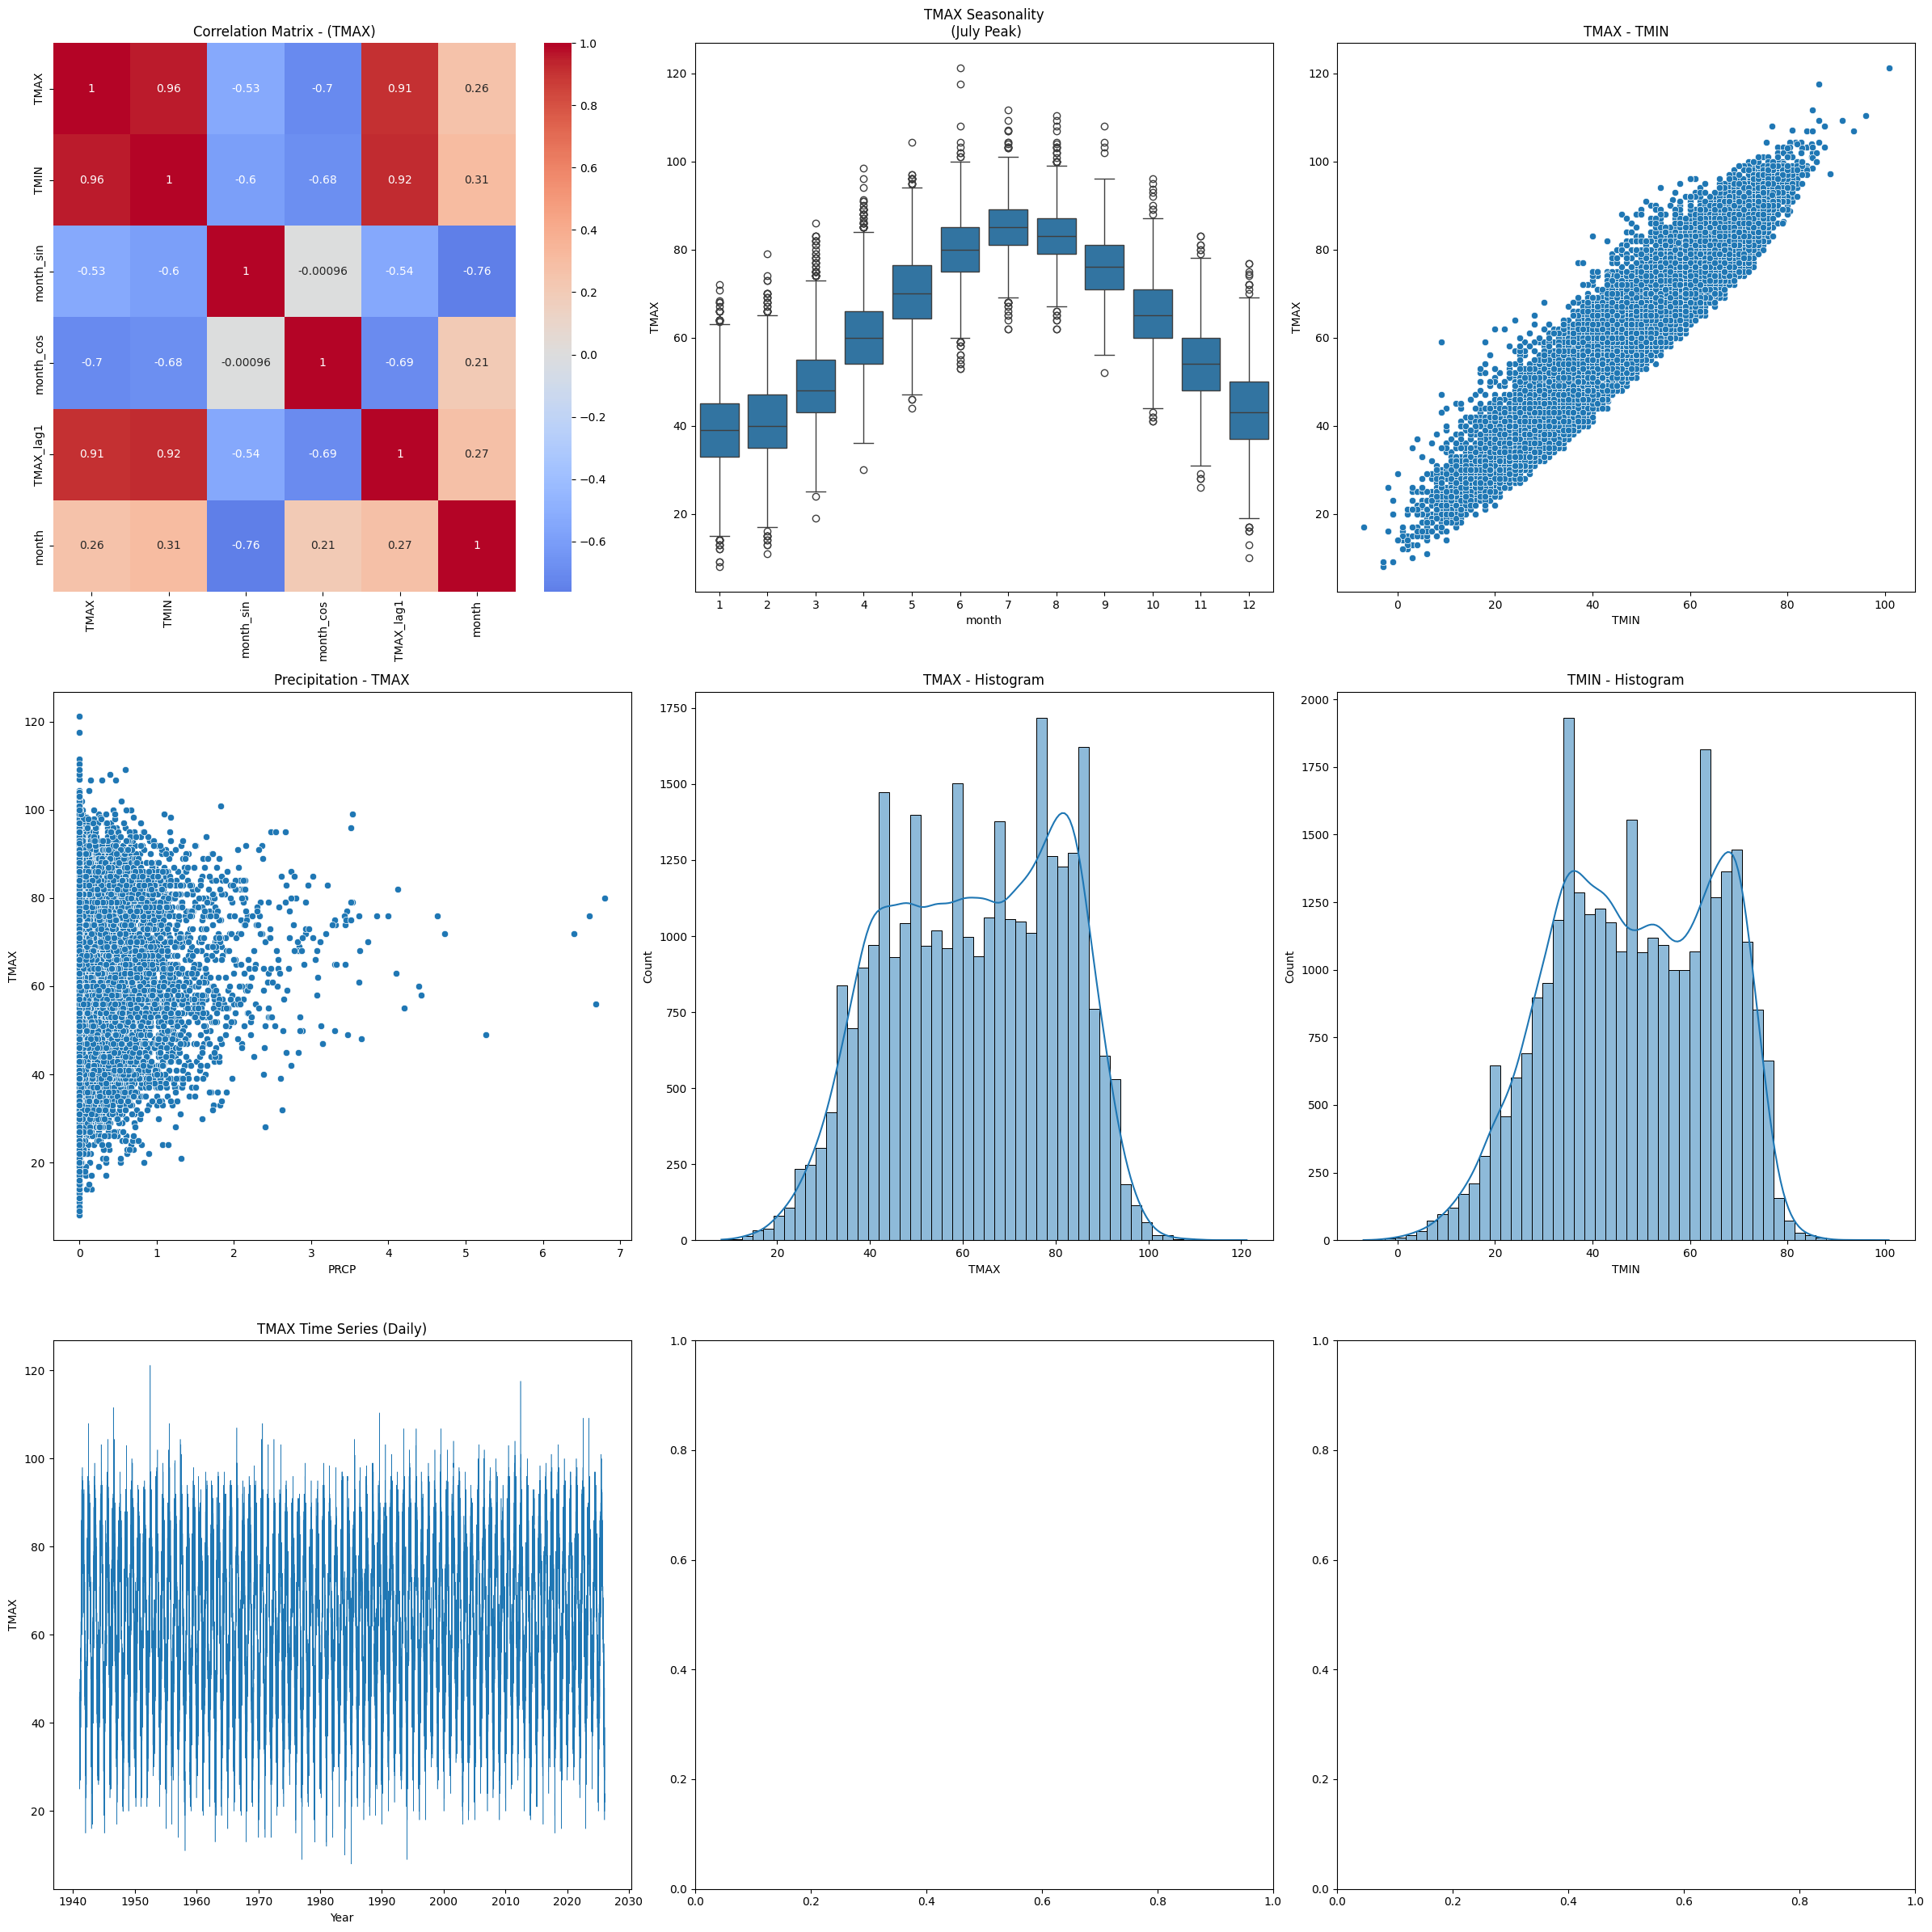

TMAX - TMIN correlation: 0.9581341717098912
July TMAX median: 85.0


In [ ]:
# Exporatory Data Analysis
fig, axes = plt.subplots(3, 3, figsize=(24, 24))

# Correlation Heatmap
correlation_columns = ['TMAX', 'TMIN', 'month_sin', 'month_cos', 'TMAX_lag1', 'month']
correlation_matrix = temp_df_noisy[correlation_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0,0])
axes[0,0].set_title('Correlation Matrix - (TMAX)')

# Seasonality
sns.boxplot(x='month', y='TMAX', data=temp_df_noisy, ax=axes[0,1])
axes[0,1].set_title('TMAX Seasonality\n (July Peak)')

# TMAX - TMIN
sns.scatterplot(x='TMIN', y='TMAX', data=temp_df_noisy, ax=axes[0,2])
axes[0,2].set_title('TMAX - TMIN')

# PRCP - TMAX
sns.scatterplot(x='PRCP', y='TMAX', data=temp_df_noisy, ax=axes[1,0])
axes[1,0].set_title('Precipitation - TMAX')

# TMAX Histogram
sns.histplot(temp_df_noisy['TMAX'], bins=50, kde=True, ax=axes[1,1])
axes[1,1].set_title('TMAX - Histogram')

# TMIN Histogram
sns.histplot(temp_df_noisy['TMIN'], bins=50, kde=True, ax=axes[1,2])
axes[1,2].set_title('TMIN - Histogram')

# TMAX over the years
axes[2,0].plot(temp_df_noisy['DATE'], temp_df_noisy['TMAX'], linewidth=0.4)
axes[2,0].set_title('TMAX Time Series (Daily)')
axes[2,0].set_xlabel('Year')
axes[2,0].set_ylabel('TMAX')


plt.tight_layout()
plt.savefig('eda_graphs.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'TMAX - TMIN correlation: {correlation_matrix.loc['TMAX', 'TMIN']}')
print(f'July TMAX median: {temp_df_noisy[temp_df_noisy['month']==7]['TMAX'].median()}')

# Model Development and Evaluation

In [ ]:
# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, classification_report, silhouette_score
from sklearn.cluster import KMeans

# Prepare data for models
model_features = ['TMAX_lag1', 'TMIN', 'PRCP', 'AWND', 'month_sin', 'month_cos']
X = temp_df_noisy[model_features].dropna()
y_regression = temp_df_noisy.loc[X.index, 'TMAX']

# Split the time at a specific date
split_date = '2021-01-01'
# Create a mask from every value before the split date
training_mask = temp_df_noisy['DATE'] < split_date
# training = before split date, test = after split date
X_train, y_train = X[training_mask], y_regression[training_mask]
X_test, y_test = X[~training_mask], y_regression[~training_mask]
print(f'Train: {X_train.shape}, Test: {X_test.shape}')



Train: (13513, 6), Test: (1843, 6)


/tmp/ipykernel_13127/2891788162.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train, y_train = X[training_mask], y_regression[training_mask]
/tmp/ipykernel_13127/2891788162.py:19: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test, y_test = X[~training_mask], y_regression[~training_mask]


# Regression Models

In [ ]:
# All Regression Models
regression_models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(max_depth=10, random_state=101),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=101)
}

regression_results = {}

for name, model in regression_models.items():
  model.fit(X_train, y_train)
  y_prediction = model.predict(X_test)
  regression_results[name] = {
      'R_Squared': r2_score(y_test, y_prediction),
      'RMSE': np.sqrt(mean_squared_error(y_test, y_prediction)),
      'MAE': mean_absolute_error(y_test, y_prediction)
  }
  print(f'{name:20}: R Squared = {regression_results[name]['R_Squared']:.2f}\n{name:20}: RMSE = {regression_results[name]['RMSE']:.2f}\n{name:20}: MAE = {regression_results[name]['MAE']:.2f}')

# Program shows random forest had the best R_Squared score + lowest RMSE and MAE
best_model = regression_models['RandomForest']

y_future_prediction = best_model.predict(X_test)

future_prediction_df = pd.DataFrame({
    'DATE': temp_df_noisy.loc[X_test.index, 'DATE'],
    'TMAX_actual': y_test,
    'TMAX_predicted': y_future_prediction
})

print(f"\nFirst 10 TMAX predictions:\n{future_prediction_df.head(10)}")



LinearRegression    : R Squared = 0.93
LinearRegression    : RMSE = 4.77
LinearRegression    : MAE = 3.67
DecisionTree        : R Squared = 0.92
DecisionTree        : RMSE = 4.95
DecisionTree        : MAE = 3.74
RandomForest        : R Squared = 0.93
RandomForest        : RMSE = 4.74
RandomForest        : MAE = 3.65

First 10 TMAX predictions:
            DATE  TMAX_actual  TMAX_predicted
29220 2021-01-01         41.0       47.633911
29221 2021-01-02         52.0       48.363247
29222 2021-01-03         40.0       48.602534
29223 2021-01-04         44.0       48.889913
29224 2021-01-05         42.0       50.279110
29225 2021-01-06         43.0       48.396330
29226 2021-01-07         44.0       45.068091
29227 2021-01-08         39.0       43.721871
29228 2021-01-09         38.0       40.004099
29229 2021-01-10         43.0       44.031670


# Classification Model
25+ degree's = hot day, else is a cold day.

In [ ]:
# Classifications: Hot (>25) - Cold
# >25 = hot day, <25 = cold day
y_train_classification = (y_train > 25).astype(int)
y_test_classification = (y_test > 25).astype(int)
TreeClassifier = DecisionTreeClassifier(max_depth=10, random_state=101)
TreeClassifier.fit(X_train, y_train_classification)
y_prediction_classification = TreeClassifier.predict(X_test)
classification_results = classification_report(y_test_classification, y_prediction_classification, output_dict=True)



# Clustering Model

In [ ]:
# Clustering: 4 Weather Regimes
kmeans = KMeans(n_clusters=4, random_state=101)
kmeans.fit(X_train)
silhouette_scr = silhouette_score(X_train, kmeans.labels_)



# Show Results

In [ ]:
# Results Printed
results_df = pd.DataFrame({
    'Model': ['LinearRegression', 'DecisionTree_Reg', 'RandomForest_Reg',
              'DecisionTree_Class', 'KMeans'],
    'Type': ['Regression', 'Regression', 'Regression', 'Classification', 'Clustering'],
    'Score': [
        f"R2: {regression_results['LinearRegression']['R_Squared']:.3f}, RMSE: {regression_results['LinearRegression']['RMSE']:.2f}, MAE: {regression_results['LinearRegression']['MAE']:.2f}",
        f"R2: {regression_results['DecisionTree']['R_Squared']:.3f}, RMSE: {regression_results['DecisionTree']['RMSE']:.2f}, MAE: {regression_results['DecisionTree']['MAE']:.2f}",
        f"R2: {regression_results['RandomForest']['R_Squared']:.3f}, RMSE: {regression_results['RandomForest']['RMSE']:.2f}, MAE: {regression_results['RandomForest']['MAE']:.2f}",
        f"{classification_results['accuracy']:.3f}",
        f"{silhouette_scr:.3f}"
    ]
})
print("RESULTS TABLE:")
print(results_df.to_markdown(index=False))
# Save results to csv
results_df.to_csv('model_results.csv')

print("Classification macro average")
print(classification_results['macro avg'])

RESULTS TABLE:
| Model              | Type           | Score                            |
|:-------------------|:---------------|:---------------------------------|
| LinearRegression   | Regression     | R2: 0.928, RMSE: 4.77, MAE: 3.67 |
| DecisionTree_Reg   | Regression     | R2: 0.923, RMSE: 4.95, MAE: 3.74 |
| RandomForest_Reg   | Regression     | R2: 0.929, RMSE: 4.74, MAE: 3.65 |
| DecisionTree_Class | Classification | 0.992                            |
| KMeans             | Clustering     | 0.416                            |
Classification macro average
{'precision': 0.6480905619203492, 'recall': 0.6480905619203492, 'f1-score': 0.6480905619203492, 'support': 1843.0}


# Testing with and without the lag feature

In [ ]:
# Testing RF without lag
# Features without lag
model_features_without_lag = ['TMIN', 'PRCP', 'AWND', 'month_sin', 'month_cos']
X_without = temp_df_noisy[model_features_without_lag].dropna()
X_train_without = X_without[training_mask]
X_test_without = X_without[~training_mask]

# Train RF without lag
rf_without = RandomForestRegressor(n_estimators=100, random_state=101)
rf_without.fit(X_train_without, y_train)
y_pred_without = rf_without.predict(X_test_without)
r2_without = r2_score(y_test, y_pred_without)
rmse_without = np.sqrt(mean_squared_error(y_test, y_pred_without))

# RF with lag (from your existing results)
r2_with = regression_results['RandomForest']['R_Squared']
rmse_with = regression_results['RandomForest']['RMSE']

# Compare
print()
print(f"Random Forest R-squared WITH lag: {r2_with:.3f}")
print(f"Random Forest R-squared WITHOUT lag: {r2_without:.3f}")
print(f"Improvement in R-squared: {r2_with - r2_without:.3f}")
print()
print(f"Random Forest RMSE WITH lag: {rmse_with:.2f}")
print(f"Random Forest RMSE WITHOUT lag: {rmse_without:.2f}")
print(f"Improvement in RMSE : {rmse_without - rmse_with:.2f}")

/tmp/ipykernel_13127/3111855181.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train_without = X_without[training_mask]
/tmp/ipykernel_13127/3111855181.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test_without = X_without[~training_mask]



Random Forest R-squared WITH lag: 0.929
Random Forest R-squared WITHOUT lag: 0.921
Improvement in R-squared: 0.008

Random Forest RMSE WITH lag: 4.74
Random Forest RMSE WITHOUT lag: 5.01
Improvement in RMSE : 0.27


# Graphs

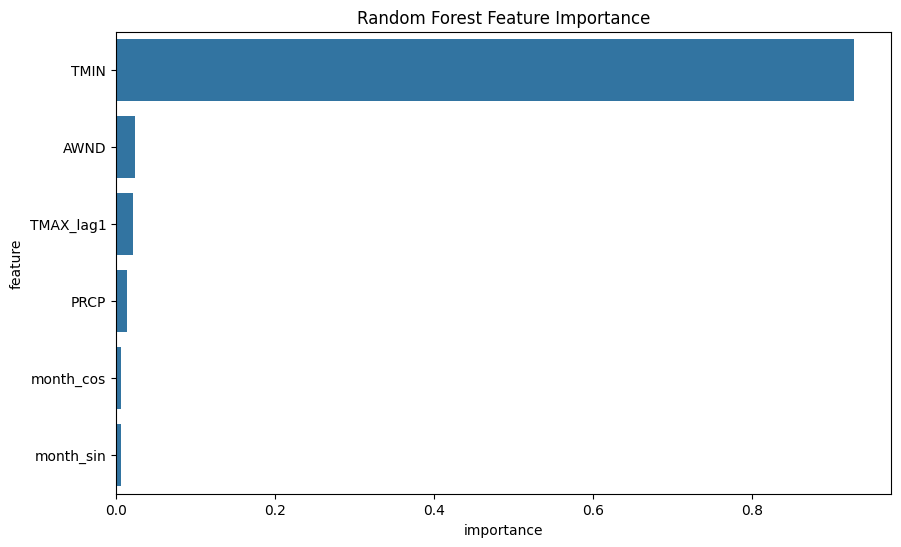

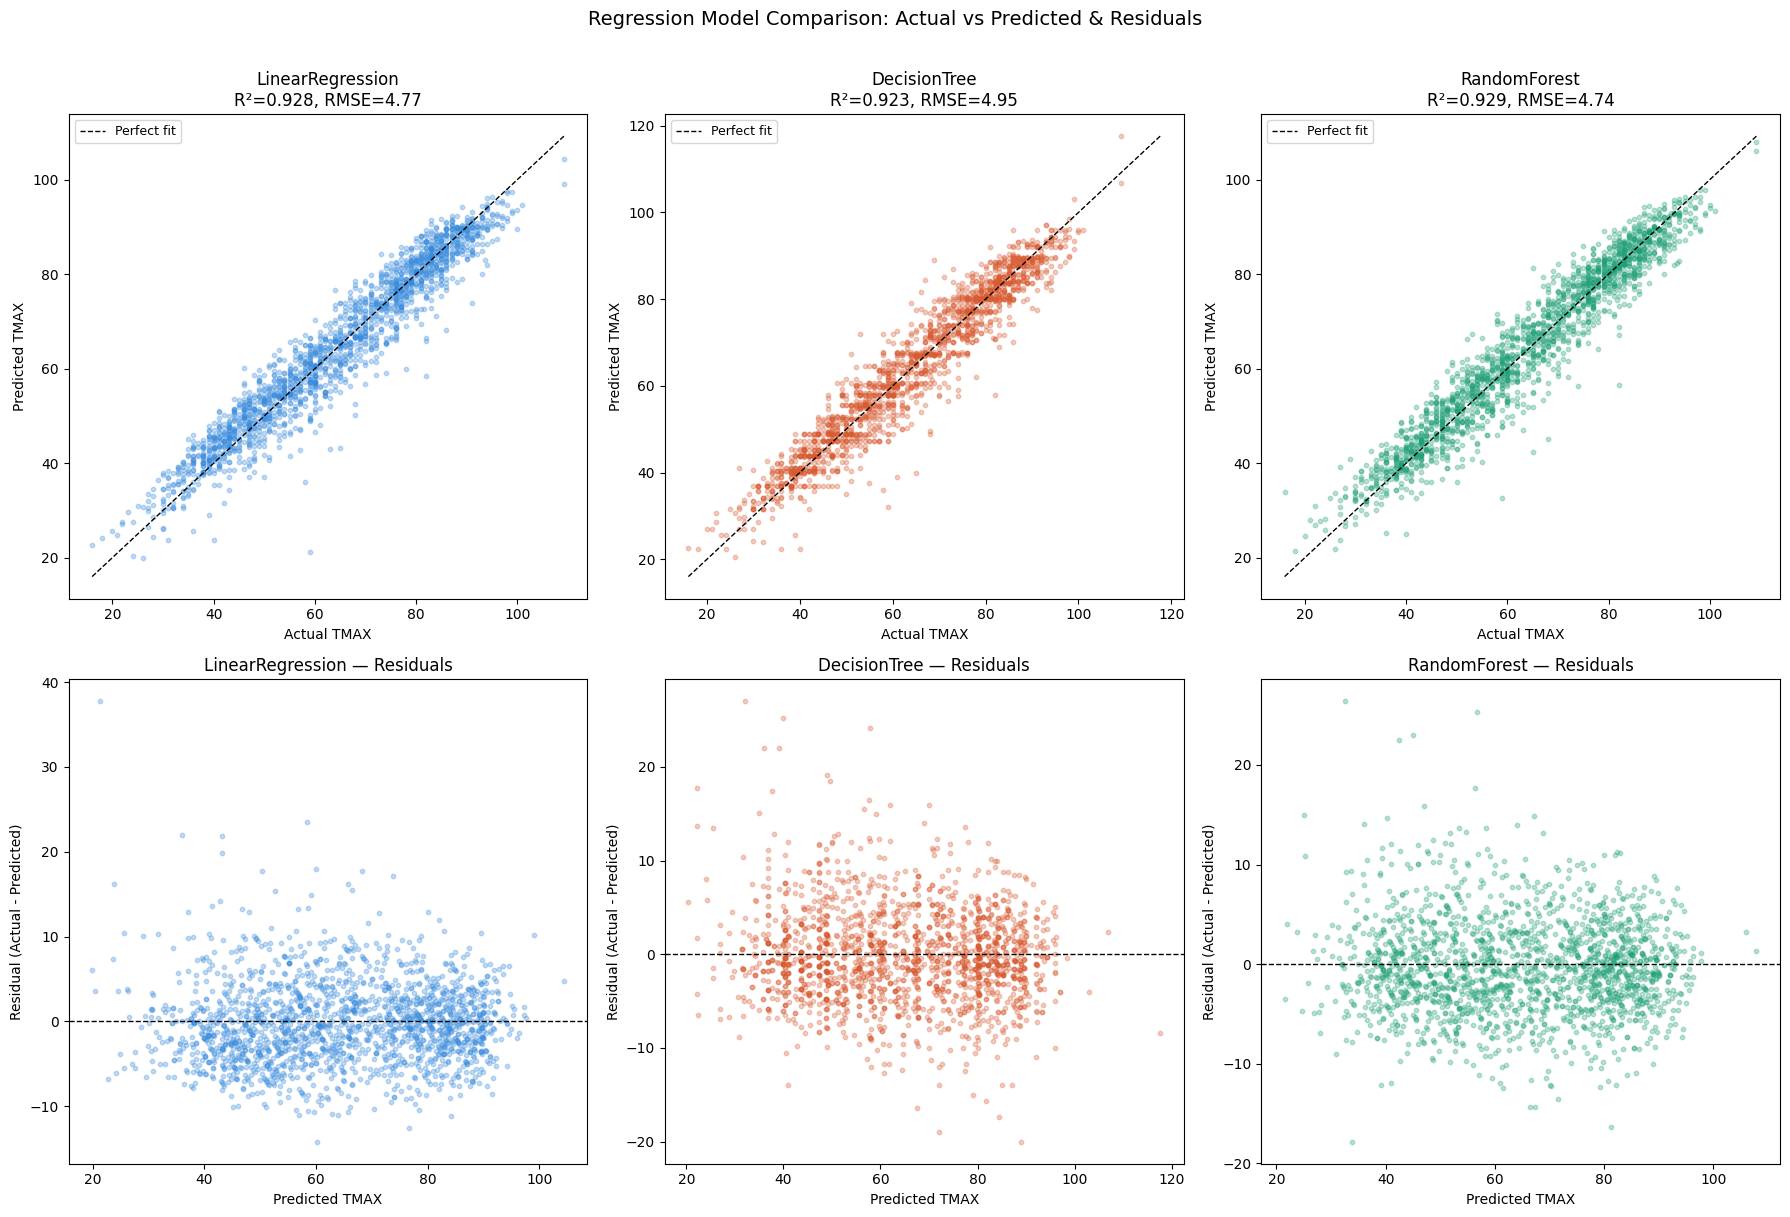

In [ ]:
# Feature Importance
plt.figure(figsize=(10, 6))
randomforest_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': regression_models['RandomForest'].feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=randomforest_importance, x='importance', y='feature')
plt.title('Random Forest Feature Importance')
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

model_names = ['LinearRegression', 'DecisionTree', 'RandomForest']
colors = ['#378ADD', '#D85A30', '#1D9E75']

# Store all predictions
all_predictions = {}
for name, model in regression_models.items():
    all_predictions[name] = model.predict(X_test)

# Row 1: Actual vs Predicted
for i, (name, color) in enumerate(zip(model_names, colors)):
    y_pred = all_predictions[name]
    r2 = regression_results[name]['R_Squared']
    rmse = regression_results[name]['RMSE']

    axes[0, i].scatter(y_test, y_pred, alpha=0.3, s=10, color=color)

    # Perfect fit line
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[0, i].plot(lims, lims, 'k--', linewidth=1, label='Perfect fit')

    axes[0, i].set_xlabel('Actual TMAX')
    axes[0, i].set_ylabel('Predicted TMAX')
    axes[0, i].set_title(f'{name}\nR²={r2:.3f}, RMSE={rmse:.2f}')
    axes[0, i].legend(fontsize=9)

# Row 2: Residuals
for i, (name, color) in enumerate(zip(model_names, colors)):
    y_pred = all_predictions[name]
    residuals = y_test - y_pred

    axes[1, i].scatter(y_pred, residuals, alpha=0.3, s=10, color=color)
    axes[1, i].axhline(0, color='black', linestyle='--', linewidth=1)

    axes[1, i].set_xlabel('Predicted TMAX')
    axes[1, i].set_ylabel('Residual (Actual - Predicted)')
    axes[1, i].set_title(f'{name} — Residuals')

plt.suptitle('Regression Model Comparison: Actual vs Predicted & Residuals',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('regression_comparison.png', dpi=300, bbox_inches='tight')
plt.show()